In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [5]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (9994, 21)

Data types:
 Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

## Initial Data Inspection

The dataset contains 9,994 rows and 21 columns with no missing values. Order Date and Ship Date were converted from text to datetime format to enable time-based analysis.

In [7]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


Sales range from 0.44 USD to 22,638 USD per order, with a median of 54.49 USD — most orders are small, but a few large ones pull the mean up. Profit ranges from -6,599 USD (a major loss) to 8,400 USD, suggesting some orders are being sold at a steep loss, likely tied to high discounts — worth investigating.

In [8]:
print("Most common Ship Mode:", df['Ship Mode'].mode()[0])
print("Most common Segment:", df['Segment'].mode()[0])
print("Most common Category:", df['Category'].mode()[0])
print("Most common Region:", df['Region'].mode()[0])

Most common Ship Mode: Standard Class
Most common Segment: Consumer
Most common Category: Office Supplies
Most common Region: West


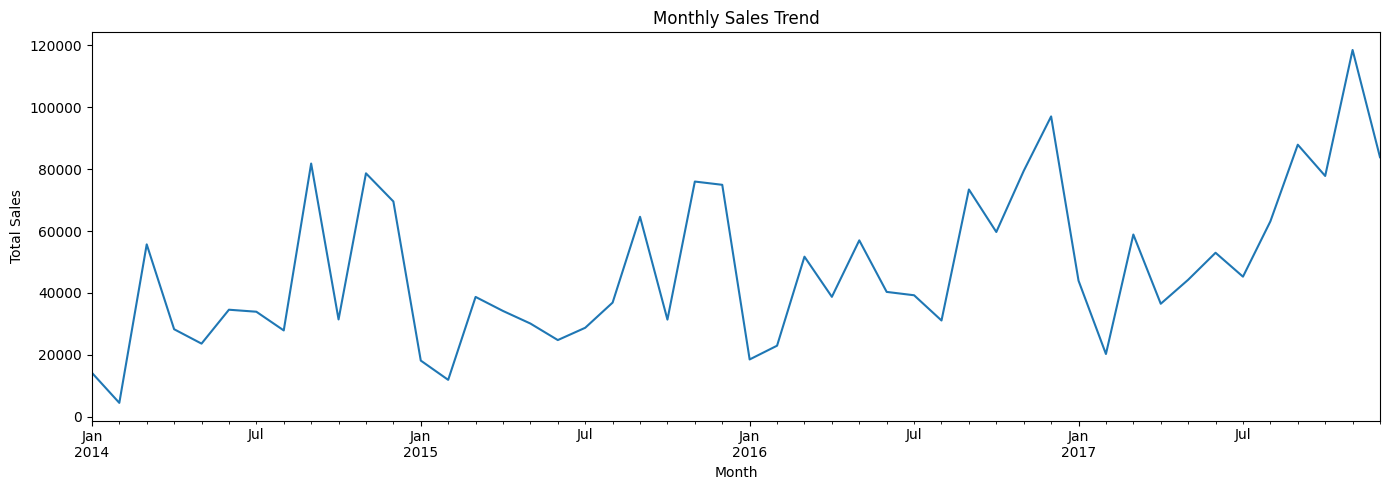

In [9]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

plt.figure(figsize=(14,5))
monthly_sales.plot(kind='line')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

Monthly sales show a clear overall upward trend from 2014 to 2017. There's a recurring seasonal pattern with sharp spikes near the end of each year (Nov-Dec), suggesting a holiday shopping surge. Sales dip noticeably in the early months of each year (Jan-Feb).

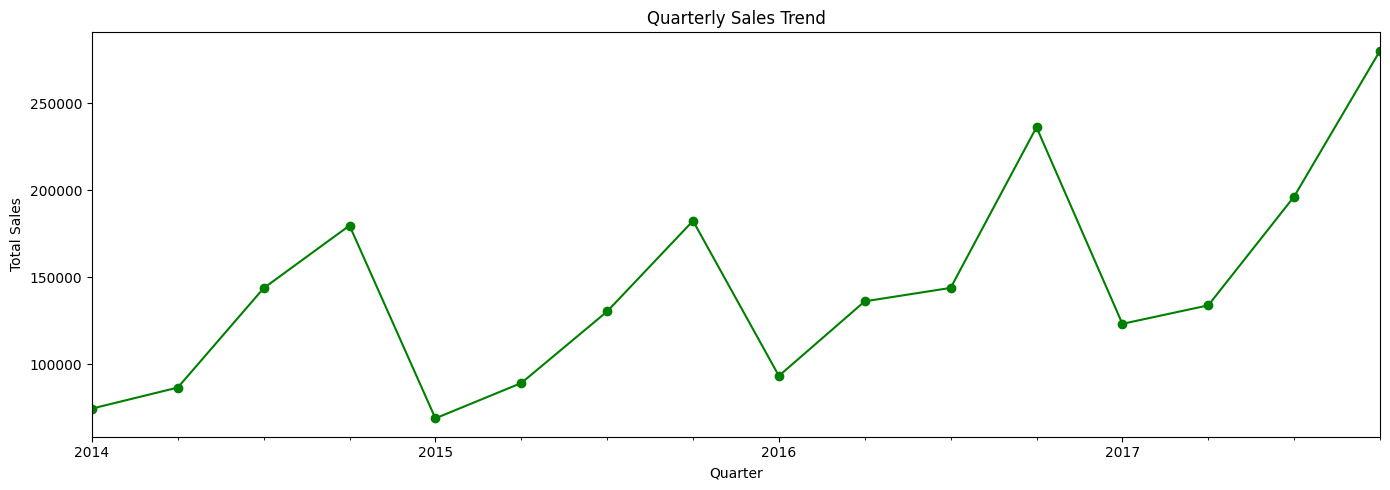

In [10]:
quarterly_sales = df.groupby(df['Order Date'].dt.to_period('Q'))['Sales'].sum()

plt.figure(figsize=(14,5))
quarterly_sales.plot(kind='line', marker='o', color='green')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

Quarterly data confirms the seasonal pattern clearly: Q4 (Oct-Dec) is consistently the strongest quarter every year, likely driven by holiday shopping. Each year's peak is higher than the last, showing healthy year-over-year growth. Q1 is consistently the weakest quarter.

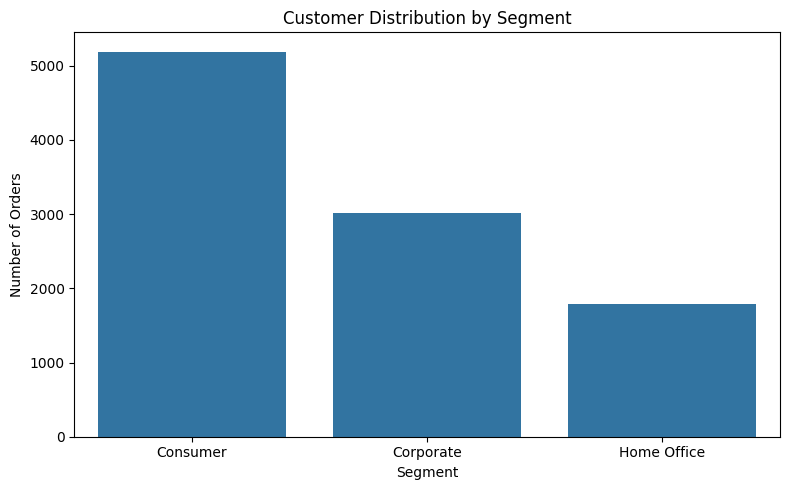

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Segment', order=df['Segment'].value_counts().index)
plt.title('Customer Distribution by Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

Consumer is by far the largest customer segment (over 5,000 orders), roughly double Corporate and nearly triple Home Office. This suggests the business's core customer base is individual/retail buyers rather than businesses.

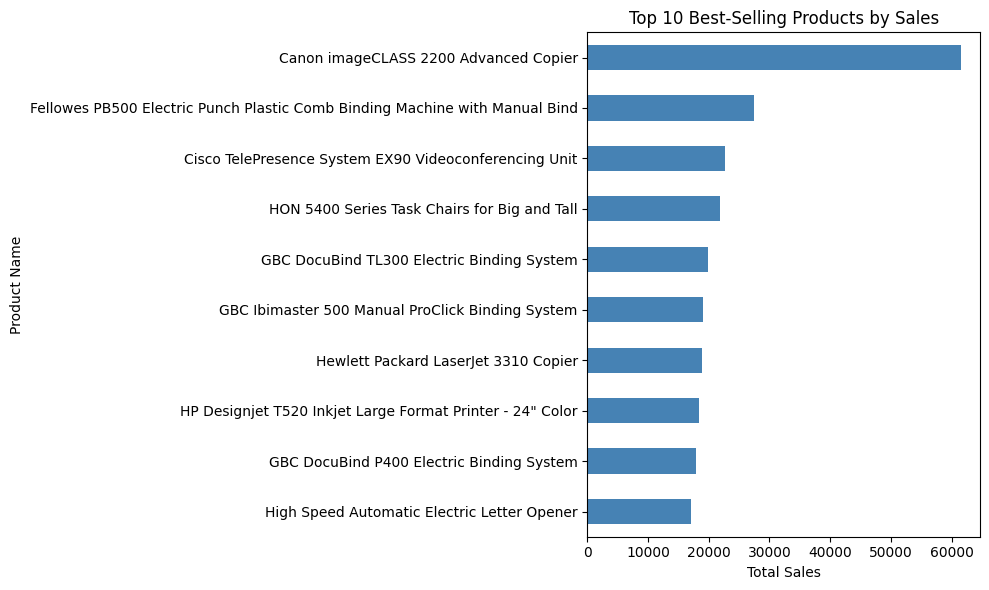

In [12]:
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)

plt.figure(figsize=(10,6))
top_products.plot(kind='barh', color='steelblue')
plt.title('Top 10 Best-Selling Products by Sales')
plt.xlabel('Total Sales')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

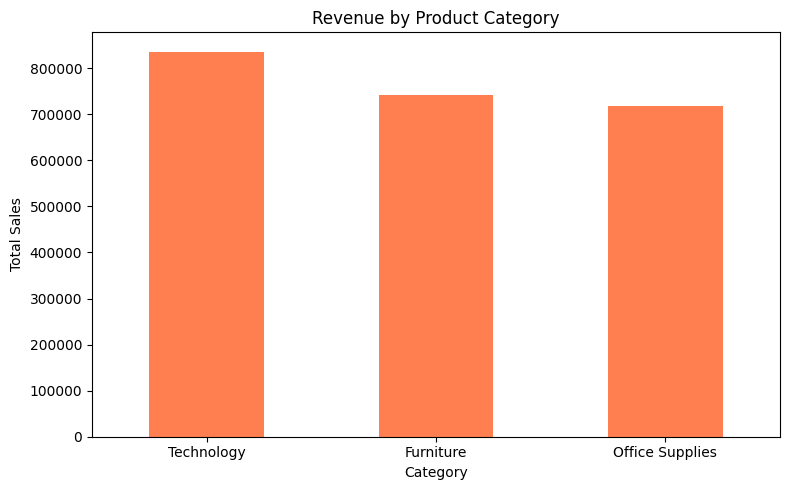

In [13]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color='coral')
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The Canon imageCLASS 2200 Advanced Copier is the single top-selling product by a wide margin — nearly double the second highest. High-value office equipment (copiers, binding machines, videoconferencing systems) dominates the top 10, rather than everyday supplies.

At the category level, Technology generates the highest revenue (~820K), followed closely by Furniture and Office Supplies (~730K and ~710K respectively) — the three categories are more balanced than the individual product ranking suggests, since Office Supplies likely sells in much higher volume at lower prices per item.

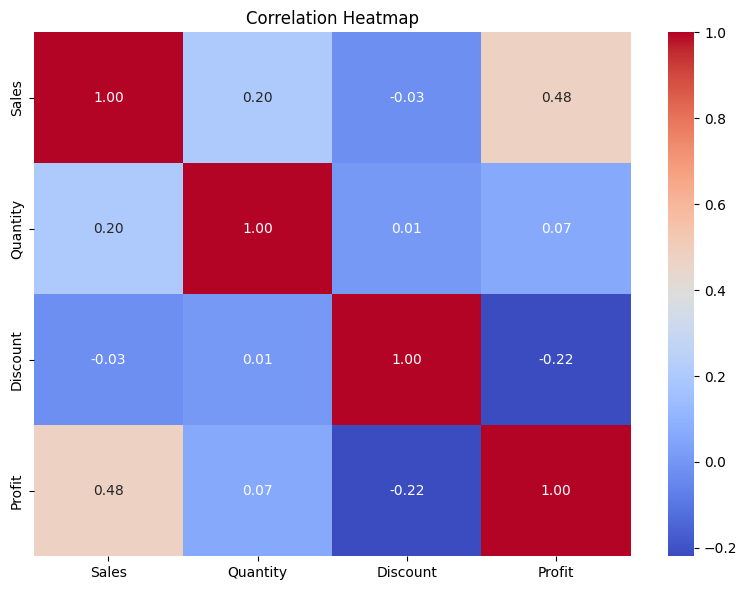

In [14]:
plt.figure(figsize=(8,6))
numeric_cols = df[['Sales', 'Quantity', 'Discount', 'Profit']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Sales and Profit have a moderate positive correlation (0.48) — more expensive orders tend to be more profitable, as expected. However, Discount and Profit are negatively correlated (-0.22), confirming that heavier discounting eats into profit margins. This matches the earlier observation of a major loss order — likely a high-discount sale. Quantity has almost no relationship with Profit (0.07), suggesting profit is driven more by pricing/discounting than by order size.

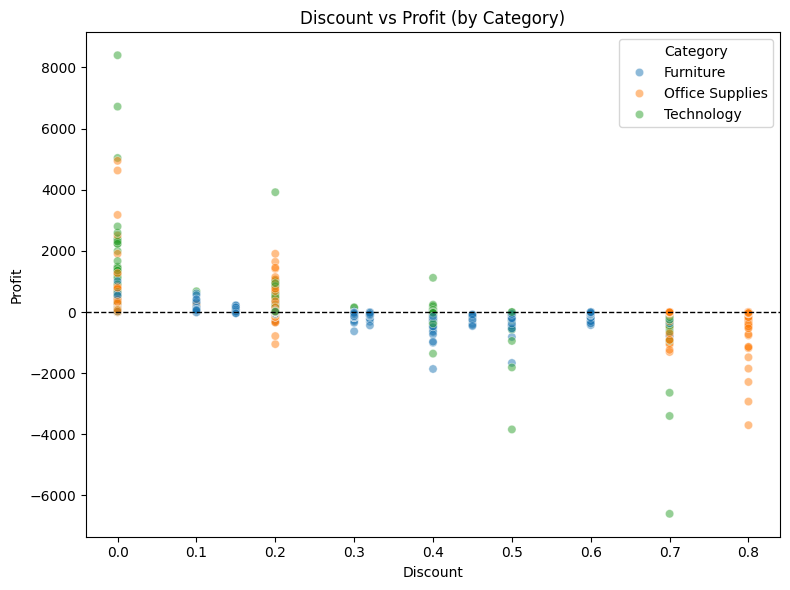

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5, hue='Category')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Discount vs Profit (by Category)')
plt.tight_layout()
plt.show()

This chart reveals a clear pattern: profit stays consistently positive when discounts are below 0.2 (20%), but starts dipping and eventually turns heavily negative once discounts exceed 0.3-0.4. At 0.7-0.8 discount levels, almost every order is a loss, including the steepest loss (-6,599) which came from a Technology item at 0.8 discount. This strongly suggests the business should cap discounts around 20-30% to protect margins.

## Conclusions & Recommendations

1. **Cap discounts at 20-30%.** Profit turns negative consistently once discounts exceed this range, especially in Technology and Office Supplies. A discount policy ceiling could recover significant lost margin.

2. **Double down on Q4 marketing.** Sales spike predictably every Q4 (Oct-Dec) — increasing inventory, staffing, and ad spend ahead of this window would capitalize on proven seasonal demand rather than reacting to it.

3. **Expand Corporate and Home Office outreach.** Consumer segment dominates orders (over 5,000 vs. ~3,000 and ~1,800), but Technology (highest revenue category) may have room to grow among underrepresented business segments through targeted B2B campaigns.

3. **Investigate high-value product bundling.** The Canon imageCLASS copier and similar big-ticket Technology items drive outsized revenue — bundling accessories or service contracts with these could increase average order value further.